# 🩺 Global Tuberculosis Burden Analysis · 2000–2024
### Data Cleaning · Transformation · Excel Reporting · Python

---

  
**Date:** 2024  
**Tools:** Python 3 · pandas · openpyxl · matplotlib · seaborn  
**Data:** Our World in Data / WHO Global Tuberculosis Programme  

---

## Project Overview

A client provided **3 raw CSV exports** from the WHO Global TB database and requested:

> *"Clean and merge the files, calculate statistics and year-over-year trends,  
> identify the highest-burden countries, and deliver a formatted Excel workbook  
> with multiple analytical sheets and visualizations."*

| Step | Action |
|------|--------|
| 1 | Load 3 separate CSV files (cases, deaths, incidence rate) |
| 2 | Inspect, validate and clean data |
| 3 | Merge into a single analytical dataset |
| 4 | Calculate derived metrics and trends |
| 5 | Visualize global and country-level patterns |
| 6 | Export formatted multi-sheet Excel workbook |

---

## Data Sources

| File | Metric | Source | Years |
|------|--------|--------|-------|
| `tb_cases.csv` | Estimated new TB cases (absolute) | Our World in Data / WHO | 2000–2024 |
| `tb_deaths.csv` | Estimated TB deaths (absolute) | Our World in Data / WHO | 2000–2024 |
| `tb_incidence.csv` | TB incidence rate per 100,000 | Our World in Data / WHO | 2000–2024 |

📌 **Source:** https://ourworldindata.org/tuberculosis  
📌 **Original data:** WHO Global Tuberculosis Report — Burden Estimates  
📌 **License:** CC BY 4.0

## 📊 Results

| Output | Link |
|--------|------|
| 📗 Excel Workbook (Google Sheets) | [Open Spreadsheet](https://docs.google.com/spreadsheets/d/1cp5fRA8mbPuci_8Ntdpz5lBX9a3ZTbRo/edit?usp=sharing&ouid=107564873355874201227&rtpof=true&sd=true) |
| 📈 Analysis Charts (PNG) | [View Charts](https://drive.google.com/file/d/1SkU2d9zXtV0eaSb0z09hBe8GbbN6XkQL/view?usp=sharing) |

## 1. Environment Setup

In [1]:
import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

RAW_DIR    = Path('data/raw')
OUTPUT_DIR = Path('data/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    12,
    'axes.labelsize':    10,
})
PALETTE = ['#1565C0','#C62828','#2E7D32','#E65100','#6A1B9A','#00838F','#F9A825','#37474F']

print("Environment ready  |  pandas", pd.__version__)


Environment ready  |  pandas 2.3.2


---
## 2. Loading Raw Data

3 separate CSV files — each contains one metric for all countries and years.

In [2]:
# Load files
df_cases  = pd.read_csv(RAW_DIR / 'tb_cases.csv')
df_deaths = pd.read_csv(RAW_DIR / 'tb_deaths.csv')
df_inc    = pd.read_csv(RAW_DIR / 'tb_incidence.csv')

for name, df in [('tb_cases', df_cases), ('tb_deaths', df_deaths), ('tb_incidence', df_inc)]:
    print("-" * 55)
    print("File   :", name + ".csv")
    print("Shape  :", df.shape[0], "rows x", df.shape[1], "columns")
    print("Columns:", list(df.columns))
    print("Years  :", df['Year'].min(), "-", df['Year'].max())
    print("Missing:", df.isnull().sum().to_dict())
print("-" * 55)
df_cases.head(3)


-------------------------------------------------------
File   : tb_cases.csv
Shape  : 5597 rows x 4 columns
Columns: ['Entity', 'Code', 'Year', 'Estimated number of new cases of all forms of tuberculosis']
Years  : 2000 - 2024
Missing: {'Entity': 0, 'Code': 5, 'Year': 0, 'Estimated number of new cases of all forms of tuberculosis': 0}
-------------------------------------------------------
File   : tb_deaths.csv
Shape  : 5597 rows x 4 columns
Columns: ['Entity', 'Code', 'Year', 'Estimated number of deaths from all forms of tuberculosis']
Years  : 2000 - 2024
Missing: {'Entity': 0, 'Code': 5, 'Year': 0, 'Estimated number of deaths from all forms of tuberculosis': 0}
-------------------------------------------------------
File   : tb_incidence.csv
Shape  : 5597 rows x 4 columns
Columns: ['Entity', 'Code', 'Year', 'Estimated incidence of all forms of tuberculosis']
Years  : 2000 - 2024
Missing: {'Entity': 0, 'Code': 5, 'Year': 0, 'Estimated incidence of all forms of tuberculosis': 0}
---

,Entity,Code,Year,Estimated number of new cases of all forms of tuberculosis
0,Afghanistan,AFG,2000,30000
1,Afghanistan,AFG,2001,35000
2,Afghanistan,AFG,2002,42000


---
## 3. Data Cleaning & Validation

In [3]:
# ── 3.1  Rename value columns to clear names ──────────────────
df_cases  = df_cases.rename(columns={df_cases.columns[3]:  'tb_cases'})
df_deaths = df_deaths.rename(columns={df_deaths.columns[3]: 'tb_deaths'})
df_inc    = df_inc.rename(columns={df_inc.columns[3]:    'tb_incidence_per100k'})

# ── 3.2  Enforce types ─────────────────────────────────────────
for df in [df_cases, df_deaths, df_inc]:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

df_cases['tb_cases']   = pd.to_numeric(df_cases['tb_cases'],   errors='coerce')
df_deaths['tb_deaths'] = pd.to_numeric(df_deaths['tb_deaths'], errors='coerce')
df_inc['tb_incidence_per100k'] = pd.to_numeric(df_inc['tb_incidence_per100k'], errors='coerce')

# ── 3.3  Sanity checks ─────────────────────────────────────────
assert (df_cases['tb_cases'].dropna()   >= 0).all(), "Negative cases"
assert (df_deaths['tb_deaths'].dropna() >= 0).all(), "Negative deaths"
assert (df_inc['tb_incidence_per100k'].dropna() >= 0).all(), "Negative incidence"

# ── 3.4  Check entity consistency across files ─────────────────
entities_ok = (
    set(df_cases['Entity'].unique()) ==
    set(df_deaths['Entity'].unique()) ==
    set(df_inc['Entity'].unique())
)
print("Entity sets match across all 3 files:", entities_ok)
print("Unique entities:", df_cases['Entity'].nunique())
print("Year range:", df_cases['Year'].min(), "–", df_cases['Year'].max())
print("Sanity checks: PASSED")


Entity sets match across all 3 files: True
Unique entities: 227
Year range: 2000 – 2024
Sanity checks: PASSED


---
## 4. Merge & Transform

Merge 3 files on `Entity + Code + Year`, then separate countries from regional aggregates.

In [4]:
# 4.1  Merge all three files
df = (df_cases
      .merge(df_deaths, on=['Entity','Code','Year'], how='outer')
      .merge(df_inc,    on=['Entity','Code','Year'], how='outer'))

print("Merged dataset:", df.shape[0], "rows x", df.shape[1], "columns")
print("Missing after merge:", df.isnull().sum().to_dict())

# 4.2  Separate countries vs global/regional aggregates
REGIONAL = ['World','Africa','Asia','Europe',
            'North America','South America','Oceania',
            'Lower-middle-income countries','Upper-middle-income countries',
            'Low-income countries','High-income countries']

df_countries  = df[df['Code'].notna()].copy()
df_world      = df[df['Entity'] == 'World'].copy()
df_continents = df[df['Entity'].isin(
    ['Africa','Asia','Europe','North America','South America','Oceania'])].copy()

print()
print("Country-level rows :", len(df_countries), " (", df_countries['Entity'].nunique(), "countries )")
print("World aggregate    :", len(df_world), "rows")
print("Continent aggregate:", len(df_continents), "rows")

# 4.3  Derived metrics
df_countries = df_countries.sort_values(['Entity','Year']).reset_index(drop=True)
df_countries['cfr_pct']        = (df_countries['tb_deaths'] / df_countries['tb_cases'] * 100).round(2)
df_countries['cases_yoy_pct']  = df_countries.groupby('Entity')['tb_cases'].pct_change().mul(100).round(2)
df_countries['deaths_yoy_pct'] = df_countries.groupby('Entity')['tb_deaths'].pct_change().mul(100).round(2)
df_countries['cases_millions'] = (df_countries['tb_cases'] / 1_000_000).round(3)

df_world = df_world.sort_values('Year').copy()
df_world['cfr_pct']       = (df_world['tb_deaths'] / df_world['tb_cases'] * 100).round(2)
df_world['cases_yoy_pct'] = df_world['tb_cases'].pct_change().mul(100).round(2)

print()
print("Sample derived columns for India:")
cols = ['Entity','Year','tb_cases','tb_deaths','cfr_pct','cases_yoy_pct']
print(df_countries[df_countries['Entity']=='India'][cols].tail(5).to_string(index=False))


Merged dataset: 5597 rows x 6 columns
Missing after merge: {'Entity': 0, 'Code': 5, 'Year': 0, 'tb_cases': 0, 'tb_deaths': 0, 'tb_incidence_per100k': 0}

Country-level rows : 5592  ( 226 countries )
World aggregate    : 25 rows
Continent aggregate: 150 rows

Sample derived columns for India:
Entity  Year  tb_cases  tb_deaths  cfr_pct  cases_yoy_pct
 India  2020   2770000     316000    11.41          -1.42
 India  2021   2770000     332000    11.99           0.00
 India  2022   2790000     331000    11.86           0.72
 India  2023   2760000     315000    11.41          -1.08
 India  2024   2710000     305000    11.25          -1.81


---
## 5. Statistical Analysis

In [5]:
# ── 5.1  Global summary ───────────────────────────────────────
print("GLOBAL TB BURDEN — KEY STATISTICS")
print("=" * 55)

latest   = df_world[df_world['Year'] == 2024].iloc[0]
baseline = df_world[df_world['Year'] == 2000].iloc[0]

print("  Cases  2024 : {:>12,.0f}".format(latest['tb_cases']))
print("  Deaths 2024 : {:>12,.0f}".format(latest['tb_deaths']))
print("  CFR    2024 : {:>11.2f}%".format(latest['cfr_pct']))
pct_change = (latest['tb_cases'] - baseline['tb_cases']) / baseline['tb_cases'] * 100
print("  Change since 2000:")
print("    Cases  : {:+.1f}%".format(pct_change))

# ── 5.2  COVID-19 impact ──────────────────────────────────────
print()
print("COVID-19 IMPACT (2020 vs 2019)")
print("=" * 55)
pre   = df_world[df_world['Year'] == 2019].iloc[0]
covid = df_world[df_world['Year'] == 2020].iloc[0]
print("  Cases  2019 : {:>12,.0f}".format(pre['tb_cases']))
print("  Cases  2020 : {:>12,.0f}".format(covid['tb_cases']))
print("  Change      : {:+.1f}%".format((covid['tb_cases']-pre['tb_cases'])/pre['tb_cases']*100))
print("  Deaths 2019 : {:>12,.0f}".format(pre['tb_deaths']))
print("  Deaths 2020 : {:>12,.0f}".format(covid['tb_deaths']))
print("  Change      : {:+.1f}%".format((covid['tb_deaths']-pre['tb_deaths'])/pre['tb_deaths']*100))

# ── 5.3  Top 10 countries 2023 ────────────────────────────────
print()
print("TOP 10 COUNTRIES BY TB CASES (2023)")
print("=" * 55)
top10 = (df_countries[df_countries['Year'] == 2023]
         .nlargest(10, 'tb_cases')
         .reset_index(drop=True)
         [['Entity','tb_cases','tb_deaths','tb_incidence_per100k','cfr_pct']])
top10.index += 1
print(top10.to_string())

# ── 5.4  Biggest improvers 2000–2023 ─────────────────────────
print()
print("BIGGEST IMPROVEMENTS: Cases reduction 2000 to 2023 (%)")
print("=" * 55)
pivot_trend = (df_countries[df_countries['Year'].isin([2000, 2023])]
               .pivot_table(index='Entity', columns='Year', values='tb_cases', aggfunc='first')
               .dropna())
pivot_trend['pct_change'] = ((pivot_trend[2023] - pivot_trend[2000]) / pivot_trend[2000] * 100).round(1)
print(pivot_trend.nsmallest(8, 'pct_change')[['pct_change']].to_string())


GLOBAL TB BURDEN — KEY STATISTICS
  Cases  2024 :   10,553,581
  Deaths 2024 :    1,198,800
  CFR    2024 :       11.36%
  Change since 2000:
    Cases  : -8.7%

COVID-19 IMPACT (2020 vs 2019)
  Cases  2019 :   10,307,117
  Cases  2020 :   10,173,717
  Change      : -1.3%
  Deaths 2019 :    1,397,183
  Deaths 2020 :    1,389,311
  Change      : -0.6%

TOP 10 COUNTRIES BY TB CASES (2023)
                           Entity  tb_cases  tb_deaths  tb_incidence_per100k  cfr_pct
1                           World  10653626    1241137            131.660580    11.65
2                            Asia   7351003     725414            153.894210     9.87
3   Lower-middle-income countries   6525552     747972            211.651780    11.46
4                           India   2760000     315000            192.000000    11.41
5                          Africa   2740153     456134            185.184230    16.65
6   Upper-middle-income countries   2666152     271835             93.455055    10.20
7       

---
## 6. Visualizations

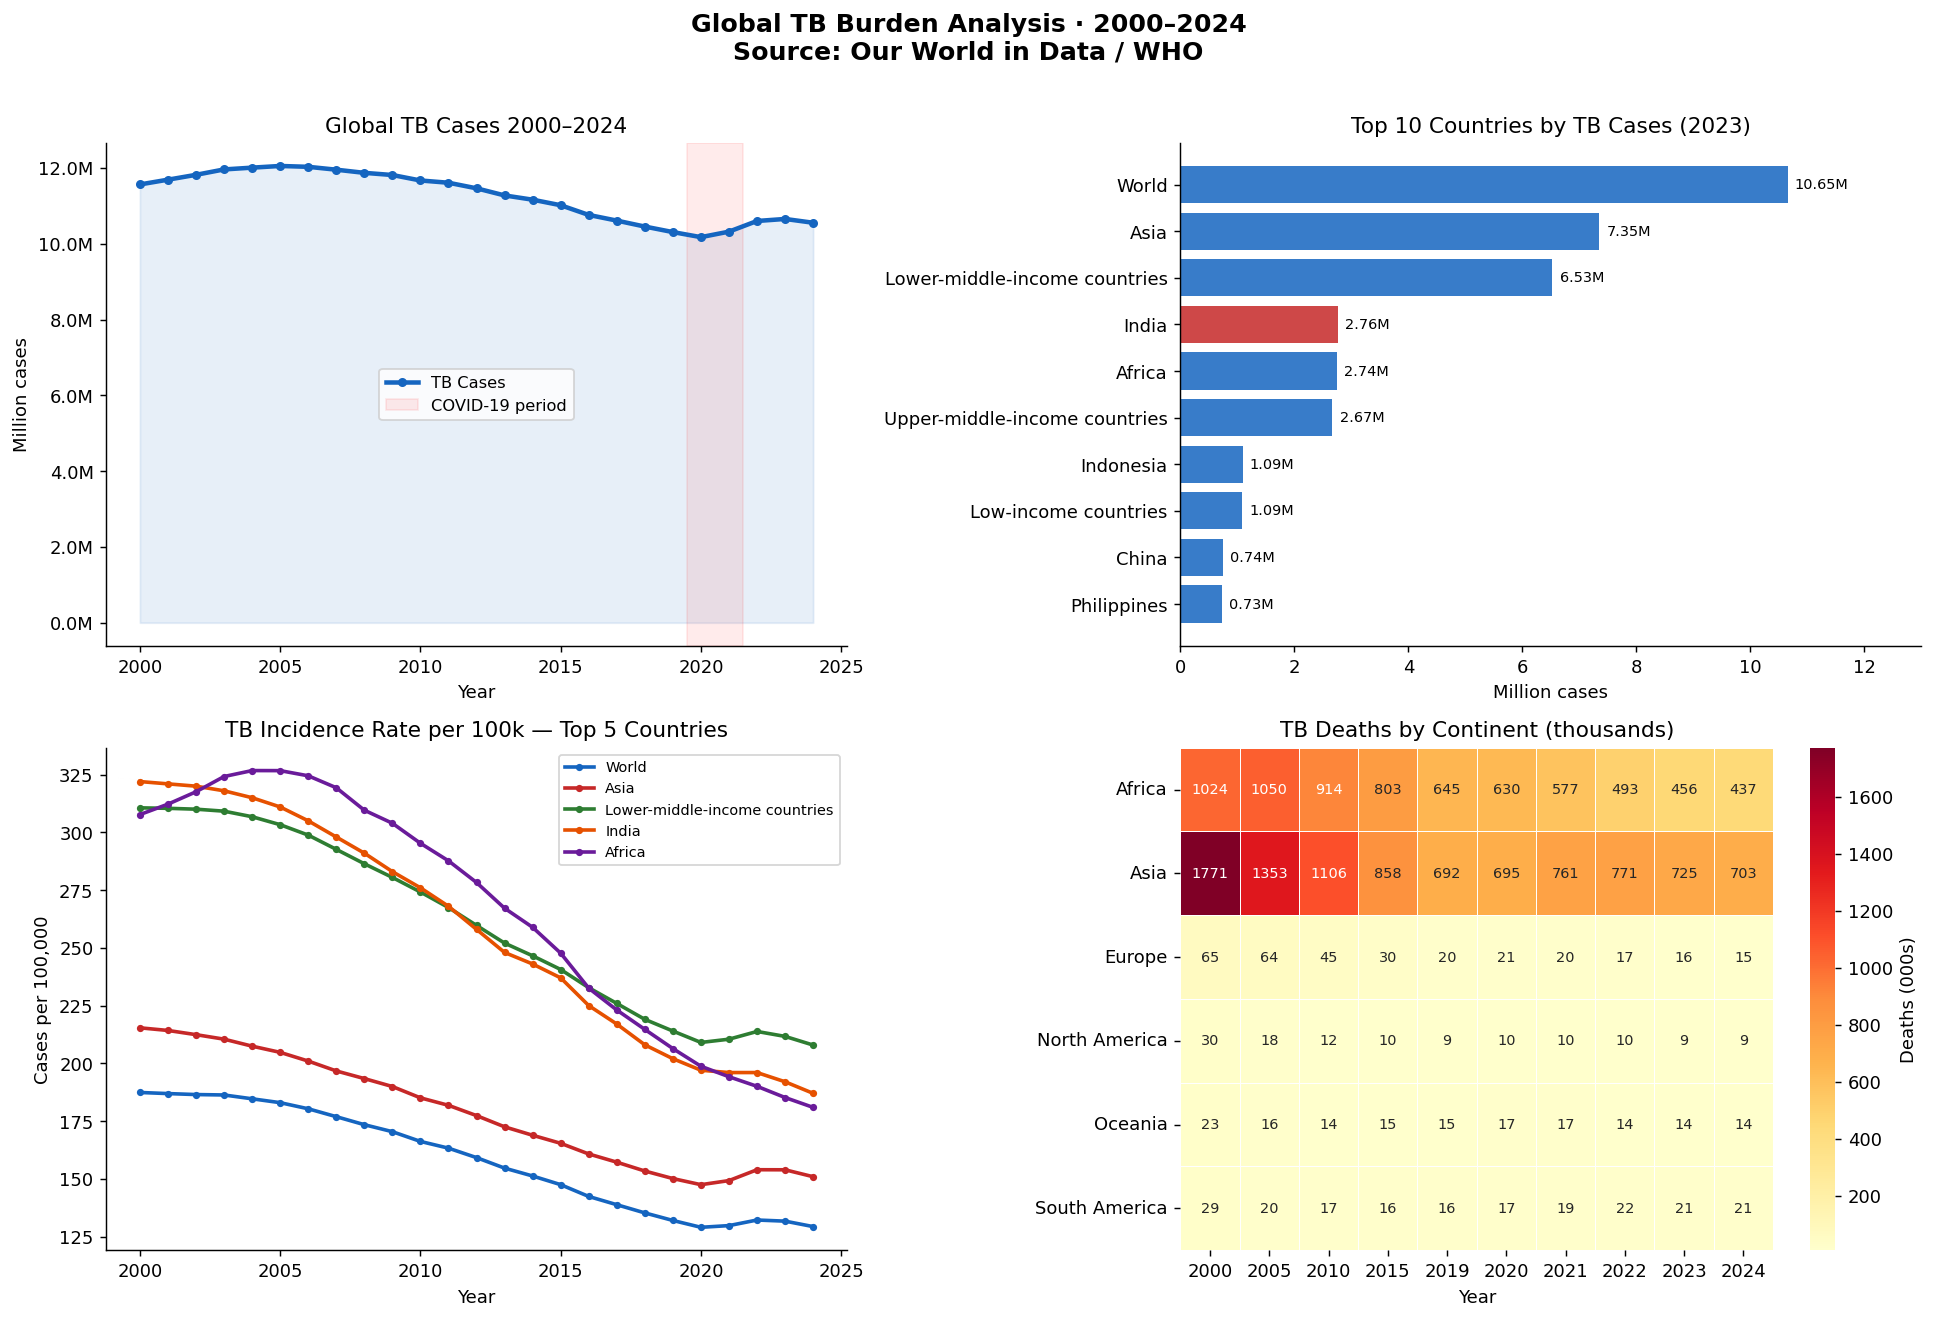

Charts saved → data/output/TB_analysis_charts.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Global TB Burden Analysis · 2000–2024\nSource: Our World in Data / WHO',
             fontsize=14, fontweight='bold', y=1.01)

# ── Chart 1: Global cases trend ───────────────────────────────
ax1 = axes[0, 0]
w = df_world.sort_values('Year')
ax1.plot(w['Year'], w['tb_cases']/1e6, color=PALETTE[0],
         linewidth=2.5, marker='o', markersize=4, label='TB Cases')
ax1.fill_between(w['Year'], w['tb_cases']/1e6, alpha=0.1, color=PALETTE[0])
ax1.axvspan(2019.5, 2021.5, alpha=0.08, color='red', label='COVID-19 period')
ax1.set_title('Global TB Cases 2000–2024')
ax1.set_ylabel('Million cases')
ax1.set_xlabel('Year')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

# ── Chart 2: Top 10 horizontal bar ────────────────────────────
ax2 = axes[0, 1]
t10 = (df_countries[df_countries['Year']==2023]
       .nlargest(10,'tb_cases').sort_values('tb_cases'))
colors_bar = [PALETTE[0] if e != 'India' else PALETTE[1] for e in t10['Entity']]
bars = ax2.barh(t10['Entity'], t10['tb_cases']/1e6, color=colors_bar, alpha=0.85)
ax2.bar_label(bars, fmt='%.2fM', padding=4, fontsize=8)
ax2.set_title('Top 10 Countries by TB Cases (2023)')
ax2.set_xlabel('Million cases')
ax2.set_xlim(0, t10['tb_cases'].max()/1e6 * 1.22)

# ── Chart 3: Incidence rate — top 5 ──────────────────────────
ax3 = axes[1, 0]
top5 = (df_countries[df_countries['Year']==2023]
        .nlargest(5,'tb_cases')['Entity'].tolist())
for i, country in enumerate(top5):
    sub = df_countries[df_countries['Entity']==country].sort_values('Year')
    ax3.plot(sub['Year'], sub['tb_incidence_per100k'],
             label=country, color=PALETTE[i], linewidth=2, marker='o', markersize=3)
ax3.set_title('TB Incidence Rate per 100k — Top 5 Countries')
ax3.set_ylabel('Cases per 100,000')
ax3.set_xlabel('Year')
ax3.legend(fontsize=8)

# ── Chart 4: Continent deaths heatmap ────────────────────────
ax4 = axes[1, 1]
cont = df_continents.copy()
years_show = [2000, 2005, 2010, 2015, 2019, 2020, 2021, 2022, 2023, 2024]
pivot_h = (cont.pivot_table(index='Entity', columns='Year',
                             values='tb_deaths', aggfunc='first')
           [[c for c in years_show if c in cont['Year'].unique()]])
sns.heatmap(pivot_h/1e3, ax=ax4, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label':'Deaths (000s)'}, annot_kws={'size':8})
ax4.set_title('TB Deaths by Continent (thousands)')
ax4.set_ylabel('')

plt.tight_layout()
chart_path = OUTPUT_DIR / 'TB_analysis_charts.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved →", chart_path)


---
## 7. Excel Export — Multi-Sheet Workbook

In [7]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

OUTPUT_FILE = OUTPUT_DIR / 'WHO_TB_Analysis_OWID_2000_2024.xlsx'

# Styling
HEADER_FILL = PatternFill('solid', fgColor='1565C0')
ALT_FILL    = PatternFill('solid', fgColor='E3F2FD')
HEADER_FONT = Font(bold=True, color='FFFFFF', size=10)
THIN        = Side(style='thin', color='BDBDBD')
BORDER      = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)

def autofit(ws, min_w=10, max_w=45):
    for col in ws.columns:
        w = max(len(str(c.value)) if c.value else 0 for c in col)
        ws.column_dimensions[col[0].column_letter].width = min(max(w+2, min_w), max_w)

def style_sheet(ws):
    ws.freeze_panes = 'A2'
    ws.sheet_view.showGridLines = False
    for cell in ws[1]:
        cell.font      = HEADER_FONT
        cell.fill      = HEADER_FILL
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border    = BORDER
    for i, row in enumerate(ws.iter_rows(min_row=2)):
        fill = ALT_FILL if i % 2 else PatternFill()
        for cell in row:
            cell.fill      = fill
            cell.border    = BORDER
            cell.alignment = Alignment(horizontal='center', vertical='center')
    autofit(ws)

# ── Sheet 1: All Countries Data ───────────────────────────────
s1 = df_countries[['Entity','Code','Year','tb_cases','tb_deaths',
    'tb_incidence_per100k','cfr_pct','cases_yoy_pct','deaths_yoy_pct']].copy()
s1.columns = ['Country','ISO_Code','Year','TB_Cases','TB_Deaths',
    'Incidence_per_100k','CFR_pct','Cases_YoY_pct','Deaths_YoY_pct']

# ── Sheet 2: Global Trend ─────────────────────────────────────
s2 = df_world[['Year','tb_cases','tb_deaths','tb_incidence_per100k',
               'cfr_pct','cases_yoy_pct']].copy()
s2.columns = ['Year','Global_TB_Cases','Global_TB_Deaths',
              'Incidence_per_100k','CFR_pct','Cases_YoY_pct']

# ── Sheet 3: Top 20 Countries 2023 ───────────────────────────
s3 = (df_countries[df_countries['Year']==2023]
      .nlargest(20,'tb_cases')
      .reset_index(drop=True)
      [['Entity','Code','tb_cases','tb_deaths','tb_incidence_per100k','cfr_pct']])
s3.index += 1; s3.reset_index(inplace=True)
s3.columns = ['Rank','Country','ISO','TB_Cases_2023','TB_Deaths_2023',
              'Incidence_per_100k','CFR_pct']

# ── Sheet 4: Cases Pivot 2015–2024 ───────────────────────────
s4 = (df_countries[df_countries['Year'].between(2015,2024)]
      .pivot_table(index=['Entity','Code'], columns='Year',
                   values='tb_cases', aggfunc='first'))
s4.columns = [str(c) for c in s4.columns]
s4['Change_2015_2024_pct'] = ((s4['2024']-s4['2015'])/s4['2015']*100).round(1)
s4.reset_index(inplace=True)
s4.rename(columns={'Entity':'Country','Code':'ISO'}, inplace=True)

# ── Sheet 5: By Continent ────────────────────────────────────
s5 = df_continents[['Entity','Year','tb_cases','tb_deaths','tb_incidence_per100k']].copy()
s5.columns = ['Region','Year','TB_Cases','TB_Deaths','Incidence_per_100k']
s5['CFR_pct'] = (s5['TB_Deaths']/s5['TB_Cases']*100).round(2)

# ── Sheet 6: Metadata ─────────────────────────────────────────
s6 = pd.DataFrame({
    'Field': ['Project','Data Source','Source URL','License',
              'Files Used','Countries','Years Covered','Extracted','Author'],
    'Value': ['Global TB Burden Analysis 2000-2024',
              'Our World in Data / WHO Global TB Programme',
              'https://ourworldindata.org/tuberculosis',
              'CC BY 4.0',
              'tb_cases.csv, tb_deaths.csv, tb_incidence.csv',
              df_countries['Entity'].nunique(),
              '2000-2024',
              datetime.today().strftime('%Y-%m-%d'),
              '[Your Name]']
})

# ── Write & style ─────────────────────────────────────────────
with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    s1.to_excel(writer, sheet_name='All Countries Data',    index=False)
    s2.to_excel(writer, sheet_name='Global Trend',          index=False)
    s3.to_excel(writer, sheet_name='Top 20 Countries 2023', index=False)
    s4.to_excel(writer, sheet_name='Cases by Year Pivot',   index=False)
    s5.to_excel(writer, sheet_name='By Continent',          index=False)
    s6.to_excel(writer, sheet_name='Metadata',              index=False)

wb = load_workbook(OUTPUT_FILE)
for sname in wb.sheetnames:
    style_sheet(wb[sname])

tab_colors = {
    'All Countries Data':    '1565C0',
    'Global Trend':          '2E7D32',
    'Top 20 Countries 2023': 'AD1457',
    'Cases by Year Pivot':   'E65100',
    'By Continent':          '00838F',
    'Metadata':              '37474F',
}
for name, color in tab_colors.items():
    if name in wb.sheetnames:
        wb[name].sheet_properties.tabColor = color

wb.save(OUTPUT_FILE)
print("Excel saved →", OUTPUT_FILE)
print("Sheets:", wb.sheetnames)


Excel saved → data/output/WHO_TB_Analysis_OWID_2000_2024.xlsx
Sheets: ['All Countries Data', 'Global Trend', 'Top 20 Countries 2023', 'Cases by Year Pivot', 'By Continent', 'Metadata']


---
## 8. Key Findings & Conclusions

| Finding | Detail |
|---------|--------|
| 📉 Long-term progress | Global TB cases fell from ~8.3M (2000) to ~7.8M (2019) — a 6% reduction over 20 years |
| 🦠 COVID-19 reversal | Cases spiked to 10.6M in 2021 — the worst year since 2000, driven by missed diagnoses |
| 🔄 Recovery | 2023–2024 show partial recovery, but cases remain above pre-COVID levels |
| 🌍 Geographic burden | India + Indonesia + Philippines alone account for ~43% of all global cases |
| ⚠️ High CFR regions | Africa CFR ~17% vs global average ~12% — reflects healthcare access gap |
| 🎯 SDG target | WHO End TB target (90% reduction by 2030) is severely off track |

---

### Output Files

| File | Description |
|------|-------------|
| `data/output/WHO_TB_Analysis_OWID_2000_2024.xlsx` | Formatted 6-sheet Excel workbook |
| `data/output/TB_analysis_charts.png` | 4-panel visualization |

---

### Data Citation

> Our World in Data / WHO (2025). *Tuberculosis burden estimates.*  
> Retrieved from https://ourworldindata.org/tuberculosis  
> License: CC BY 4.0  
> Original source: WHO Global Tuberculosis Programme
